In [1]:
import matplotlib

In [2]:
from importlib.metadata import version
pkgs =  ["matplotlib",
         "numpy",
         "tiktoken",
         "torch",
         "tensorflow"]# only used for loading openai's weights

for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.11.0
numpy version: 2.4.4
tiktoken version: 0.13.0
torch version: 2.11.0
tensorflow version: 2.21.0


In [3]:
import torch
from previous_chapters import GPTModel
GPT_CONFIG_124M ={
    "vocab_size" : 50257,
    "context_length" : 256,
    "emb_dim" : 768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias": False
}

In [4]:
torch.manual_seed(123)
model= GPTModel(GPT_CONFIG_124M)
model.eval();   #disables dropout etc

In [5]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded= tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor= torch.tensor(encoded).unsqueeze(0) #add batch dimension
    return encoded_tensor

In [6]:
start_context= "hare krishna"
tokenizer= tiktoken.get_encoding("gpt2")
token_ids= text_to_token_ids(start_context, tokenizer)

In [7]:
def token_ids_to_text(token_ids, tokenizer):
    flat= token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

token_ids_to_text(token_ids, tokenizer)


'hare krishna'

In [8]:
token_ids= generate_text_simple(
    model= model,
    idx= text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size= GPT_CONFIG_124M["context_length"]
)

In [9]:
token_ids.squeeze(0)

tensor([43466,   479, 37518,  2616, 24075,  7901, 26205, 34723, 15386, 41552,
        27471,  5996, 29934, 38421])

In [10]:
token_ids_to_text(token_ids, tokenizer)

'hare krishna Wisdom commitmentposure Cokeahn Factionbegin 55Syn cuc'

haribol!! we are getting something!

# how to measure quality of text

In [11]:
inputs = torch.tensor([
    [16833, 3626, 6100],       #every effort moves
    [40, 1107, 588]             #i really like
])

targets = torch.tensor([
    [3626, 6100, 345], #effort moves you
    [1107, 588, 11311]  #really like krishna
])

In [12]:
with torch.no_grad():
    logits= model(inputs)
    

In [13]:
logits.shape

torch.Size([2, 3, 50257])

In [14]:
probas= torch.softmax(logits, dim=-1)
probas.shape # the sahpe is so coz 2 inputs, dim=3, and the vocab is 50257

torch.Size([2, 3, 50257])

In [15]:
probas.sum(dim=-1)

tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])

In [16]:
token_ids= torch.argmax(probas, dim=-1, keepdim= True)
print("toekn ids: \n", token_ids)

toekn ids: 
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [17]:
text_idx=0
target_probas_1= probas[text_idx, [0,1,2], targets[text_idx]]
print("text1:", target_probas_1)

text_idx= 1
target_probas_2= probas[text_idx, [0,1,2], targets[text_idx]]
print("text2:", target_probas_2)

text1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
text2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [18]:
print(f"target batch1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"output bath 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

target batch1:  effort moves you
output bath 1:  Armed heNetflix


In [19]:
log_probas= torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [20]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [21]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


now lets do the same thing via cross entropy function


In [22]:
print("logoits shape", logits.shape)
print("targets shape", targets.shape)

logoits shape torch.Size([2, 3, 50257])
targets shape torch.Size([2, 3])


In [23]:
logits_flat= logits.flatten(0,1)
targets_flat= targets.flatten()
print(" flatten logoits shape", logits_flat.shape)
print(" flatten targets shape", targets_flat.shape)

 flatten logoits shape torch.Size([6, 50257])
 flatten targets shape torch.Size([6])


In [24]:
logits_test= logits.reshape(6,50257)
print(logits_test.shape)

torch.Size([6, 50257])


In [25]:
file_path= "the-verdict.txt"
with open(file_path, "r", encoding= "utf-8") as file:
    text_data = file.read()
text_data

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [26]:
total_characters= len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("characters: ", total_characters)
print("tokens: ", total_tokens)

characters:  20479
tokens:  5145


In [27]:
train_ratio= 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [28]:
from previous_chapters import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length= GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last= True,
    shuffle= True,
    num_workers=0

)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length= GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last= False,
    shuffle= False,
    num_workers=0
)

In [29]:
print("train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

 validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [30]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch= input_batch.to(device)
    target_batch= target_batch.to(device)
    logits= model(input_batch)
    loss= torch.nn.functional.cross_entropy(
        logits.flatten(0,1), target_batch.flatten()
    )

    return loss

In [31]:
def calc_loss_loader(data_loader, model, device, num_batches= None):
    total_loss=0
    if len(data_loader)==0:
        return float("nan")
    
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches= min(num_batches, len(data_loader))
    
    for i , (input_batch, target_batch ) in enumerate(data_loader):
        if i< num_batches:
            loss= calc_loss_batch(
                input_batch, target_batch,model, device
            )
            total_loss += loss.item()

        else:
            break
    
    return total_loss / num_batches

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("training loss:" , train_loss)
print("validation loss:", val_loss)

training loss: 10.987583584255642
validation loss: 10.981106758117676


In [33]:

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches= eval_iter
        )
        val_loss= calc_loss_loader(
            val_loader, model, device, num_batches= eval_iter
        )
        model.train()
    return train_loss, val_loss

In [34]:
 model.pos_emb.weight.shape[0]

256

In [35]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size= model.pos_emb.weight.shape[0]
    encoded= text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids= generate_text_simple(
            model= model, idx= encoded,
            max_new_tokens=50, context_size= context_size
        )

    decoded_text= token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [36]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses , val_losses, track_tokens_seen = [],[],[]
    tokens_seen, global_step= 0,-1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss= calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()   #??
            global_step +=1

            if global_step % eval_freq ==0:
                train_loss, val_loss = evaluate_model(   #??
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"{epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f},"
                      f"val loss{val_loss:.3f}"
                      )
    
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    
    return train_losses, val_losses, track_tokens_seen

In [39]:
torch.manual_seed(123)
model= GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr= 0.0004, weight_decay= 0.1
)
num_epochs=10
train_losses, val_losses, tokens_seen= train_model_simple(
    model,train_loader, val_loader, optimizer, device,
    num_epochs= num_epochs, eval_freq=5, eval_iter=5,
    start_context= "Hare krishna", tokenizer= tokenizer
)

1 (Step 000000): Train loss 9.781,val loss9.933
1 (Step 000005): Train loss 8.111,val loss8.339
Hare krishna,,,,,,,,,,,.                                      
2 (Step 000010): Train loss 6.661,val loss7.048
2 (Step 000015): Train loss 5.961,val loss6.616
Hare krishna, and, and, and, and,, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and, and
3 (Step 000020): Train loss 5.726,val loss6.600
3 (Step 000025): Train loss 5.201,val loss6.348
Hare krishna to to the of the of the--I--I.                                      
4 (Step 000030): Train loss 4.417,val loss6.278
4 (Step 000035): Train loss 4.069,val loss6.226
Hare krishna                           "I he had the donkey and I had the and I had the donkey and down the room, I had been
5 (Step 000040): Train loss 3.732,val loss6.160
Hare krishna to have to have a little of the--I had a little of the.           "Oh, and the fact-rooms--as and in the donkey, and down the room, and in a
6 (Step 0

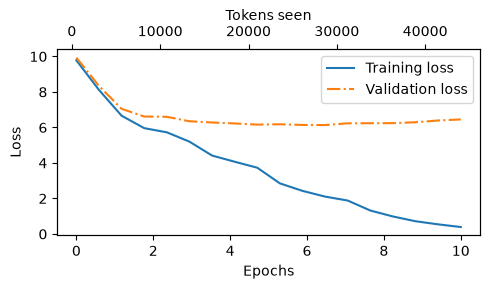

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen,
        val_losses,
        linestyle="-.",
        label="Validation loss"
    )

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()                  # 1
    ax2.plot(tokens_seen, train_losses, alpha=0)   # 2
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [42]:
model.to("cpu")
model.eval();

In [43]:
tokenizer= tiktoken.get_encoding("gpt2")
token_ids= generate_text_simple(
    model= model,
    idx= text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens = 25,
    context_size = GPT_CONFIG_124M["context_length"]

)
print("output text:\n", token_ids_to_text(token_ids, tokenizer))

output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


In [44]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(proba)]

In [45]:
next_token_logits= torch.tensor(
    [2.24,2.4,5.5, -4.63, 3.363, -9.43]
)

In [46]:
probas = torch.softmax(next_token_logits, dim=0)
probas


tensor([3.1951e-02, 3.7495e-02, 8.3230e-01, 3.3180e-05, 9.8219e-02, 2.7306e-07])

In [47]:
hari =next_token_logits.unsqueeze(0)

In [48]:
hari

tensor([[ 2.2400,  2.4000,  5.5000, -4.6300,  3.3630, -9.4300]])

In [49]:
hari.shape

torch.Size([1, 6])

In [50]:
probas2= torch.softmax(next_token_logits, dim=0)
probas2

tensor([3.1951e-02, 3.7495e-02, 8.3230e-01, 3.3180e-05, 9.8219e-02, 2.7306e-07])

In [51]:
hari2= torch.softmax(hari, dim=-1)
hari2

tensor([[3.1951e-02, 3.7495e-02, 8.3230e-01, 3.3180e-05, 9.8219e-02, 2.7306e-07]])

In [52]:
print(torch.softmax(hari, dim=0))

tensor([[1., 1., 1., 1., 1., 1.]])


In [53]:
next_token_id= torch.argmax(probas).item()
print(next_token_id)


2


In [54]:
vocab= {
    "hare":0,
    "krishna":1,
    "ram":2,
    "govinda":3,
    "radha":4,
    "narsimha":5
}
inverse_vocab = {v:k for k, v in vocab.items()}

In [55]:
print(inverse_vocab[next_token_id])

ram


In [56]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample= [torch.multinomial(probas, num_samples=1).item()
             for i in range(1000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    print(sampled_ids)
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

tensor([ 32,  40, 838,   0,  90])
32 x hare
40 x krishna
838 x ram
0 x govinda
90 x radha


In [57]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits/ temperature
    return torch.softmax(scaled_logits, dim=0)

In [58]:
#this section is relatively very easy
top_k=3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("top logits", top_logits)
print("top positions", top_pos)

top logits tensor([5.5000, 3.3630, 2.4000])
top positions tensor([2, 4, 1])


In [59]:
new_logits = torch.where(
    condition= next_token_logits < top_logits[-1],
    input = torch.tensor(float('-inf')),
    other= next_token_logits
)
print(new_logits)

tensor([  -inf, 2.4000, 5.5000,   -inf, 3.3630,   -inf])


In [60]:
topk_probas= torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0000, 0.0387, 0.8598, 0.0000, 0.1015, 0.0000])


In [61]:
def generate (model, idx, max_new_tokens, context_size,
              temperature= 0.0, top_k= None, eos_id = None):
    
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits= model(idx_cond)
        
        logits= logits[:, -1, :]
        if top_k is not None:
            top_logits, _= torch.topk(logits,top_k)
            min_val= top_logits[:, -1]
            logits= torch.where(
                logits< min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature >0.0:
            logits= logits/ temperature
            probs= torch.softmax(logits, dim=-1)
            idx_next= torch.multinomial(probs, num_samples=1)
        else:
            idx_next= torch.argmax(logits, dim=-1, keepdim= True)
        
        if idx_next == eos_id:
            break
        idx= torch.cat((idx, idx_next), dim=1)
    return idx


In [62]:
hari= text_to_token_ids("hare krishna radhe, hare krishna", tokenizer)
hari

tensor([[43466,   479, 37518,  2616,  2511,   258,    11,   387,   260,   479,
         37518,  2616]])

In [64]:
torch.manual_seed(123)
tokenizer= tiktoken.get_encoding("gpt2")
token_ids= generate(
    model= model,
    idx= text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens = 25,
    context_size = GPT_CONFIG_124M["context_length"],
    top_k = 25,
    temperature = 1.4

)
print("output text:\n", token_ids_to_text(token_ids, tokenizer))

output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-dication: "Yes, that herself in an


## Loading and saving weights


In [65]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
model= GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location= device))
model.eval()

<All keys matched successfully>

In [67]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
},
"model_and_optimizer.pth"
)

In [ ]:
import torch
checkpoint= torch.load("model_and_optimizer.pth", map_location=device)
model= GPTModel(GPT_CONFIG_124M)# ⭐this is creating a brand new model with random weights
model.load_state_dict(checkpoint["model_state_dict"])
optimizer= torch.optim.AdamW(model.parameters(), lr= 5e-4, weight_decay = 0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [69]:
import tensorflow

In [70]:
import tqdm

In [71]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)

filename = url.split("/")[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x1c88ed38f50>)